In [5]:
import matplotlib.pyplot as plt
import numpy as np
import finitewave as fw


import matplotlib.pyplot as plt

import finitewave as fw

# create a tissue:
n = 2000
m = 50

tissue = fw.CardiacTissueGrid([n, m])
# tissue.mesh[np.random.rand(n, m) < 0.3] = 2  # introduce some inexcitable regions

# set up stimulation parameters:
stim_sequence = fw.StimSequence()
stim_sequence.add_stim(fw.StimVoltageCoord(0, 1, 0, 50, 0, m))
stim_sequence.add_stim(fw.StimVoltageCoord(35, 1, 0, n, 0, m//2))

action_pot_tracker = fw.ActionPotentialGridTracker()
# to specify the mesh node under the measuring - use the cell_ind field:
# eather list or list of lists can be used
action_pot_tracker.cell_ind = [[50, 3]]
action_pot_tracker.step = 1

tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(action_pot_tracker)

simulation = fw.CardiacSimulation()
simulation.dt = 0.00002
simulation.dr = 0.01
simulation.t_max = 20
# add the tissue and the stim parameters to the model object:
simulation.cardiac_tissue = tissue
simulation.cardiac_model = fw.AlievPanfilov()
simulation.stim_sequence = stim_sequence
# simulation.tracker_sequence = tracker_sequence

# run the model:
simulation.run()

# visualize the results:
plt.imshow(simulation.cardiac_model.u, cmap='RdBu_r', origin='lower')
plt.colorbar(label='Transmembrane Potential (u)')
plt.title('Aliev-Panfilov Model - Transmembrane Potential')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()

# plot the action potential
# plt.figure()
# time = np.arange(len(action_pot_tracker.output)) * simulation.dt
# plt.plot(time, action_pot_tracker.output, label="cell_50_3")
# plt.legend(title='Aliev-Panfilov')
# plt.title('Action Potential')
# plt.grid()
# plt.show()

Running AlievPanfilov on [2000, 50] Grid:   4%|▍         | 37748/1000000 [00:10<04:32, 3536.45it/s]


SystemError: CPUDispatcher(<function matvec_and_add_numba at 0x1325cdda0>) returned a result with an exception set

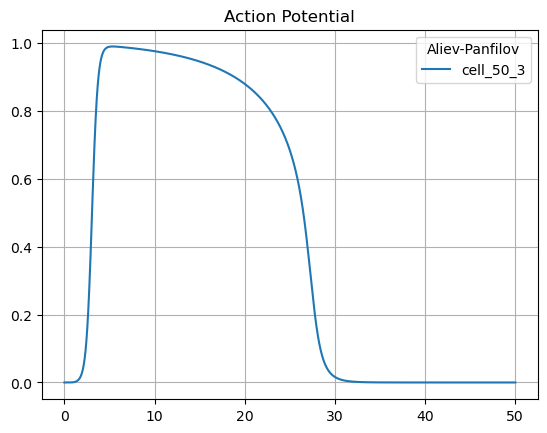

In [7]:
# plot the action potential
plt.figure()
time = np.arange(len(action_pot_tracker.output)) * simulation.dt
plt.plot(time, action_pot_tracker.output, label="cell_50_3")
plt.legend(title='Aliev-Panfilov')
plt.title('Action Potential')
plt.grid()
plt.show()

In [ ]:
26 / 